<a href="https://colab.research.google.com/github/DmitryTheSuslov/AHP_KIS/blob/main/%D0%94%D0%BC%D0%B8%D1%82%D1%80%D0%B8%D0%B9_%D0%A1%D1%83%D1%81%D0%BB%D0%BE%D0%B2_%D0%94%D0%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание  
## Имитационное моделирование систем массового обслуживания в R с использованием пакета simmer

**Выполнил: Суслов Дмитрий Сергеевич**

**Группа: ИУ5-84Б**

#ЛР3

In [1]:
install.packages("simmer")
library(simmer)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
install.packages("simmer.plot")
library(simmer.plot)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘igraph’, ‘visNetwork’, ‘DiagrammeR’


Loading required package: ggplot2


Attaching package: ‘simmer.plot’


The following objects are masked from ‘package:simmer’:

    get_mon_arrivals, get_mon_attributes, get_mon_resources




In [3]:
install.packages("ggplot2")
library(ggplot2)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
install.packages("dplyr")
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following object is masked from ‘package:ggplot2’:

    vars


The following object is masked from ‘package:simmer’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Матрица переходов состояний

In [5]:
P_orig <- matrix(c(
 0.7,0.25,0.05,0,0,0,
 0,0.75,0.20,0.05,0,0,
 0,0,0.60,0.20,0.15,0.05,
 0,0,0,0.50,0.30,0.20,
 0.85,0.15,0,0,0,0,
 0,0,0,0,0,1
),6,6,byrow=TRUE)

Без профилактики

In [6]:
P_no <- matrix(c(
 0.7,0.25,0.05,0,0,
 0,0.75,0.20,0.05,0,
 0.15,0,0.60,0.20,0.05,
 0.3,0,0,0.4,0.20,
 0,0,0,0,1
),5,5,byrow=TRUE)

Переход

In [7]:
next_state <- function(state, P){
  sample(1:nrow(P),1,prob=P[state,])
}

моделирование деградации

In [8]:
library(simmer)

simulate_chain <- function(P, weeks=100){

  state <- 1

  for(i in 1:weeks){

    state <- next_state(state,P)

    if(state==nrow(P)){
      return(i)
    }

  }

  return(weeks)
}

MTTF

In [9]:
n_sim <- 10000

times_orig <- replicate(n_sim, simulate_chain(P_orig))
times_no   <- replicate(n_sim, simulate_chain(P_no))

MTTF_orig <- mean(times_orig)
MTTF_no   <- mean(times_no)

MTTF_orig
MTTF_no

[1] 30.0238

[1] 28.786

Вероятность работы без отказа в течение 8 недель

In [10]:
simulate_survival <- function(P,weeks=8){

 state <- 1

 for(i in 1:weeks){

  state <- next_state(state,P)

  if(state==nrow(P)){
    return(0)
  }

 }

 return(1)

}

In [11]:
prob_orig <- mean(replicate(50000, simulate_survival(P_orig,8)))
prob_no   <- mean(replicate(50000, simulate_survival(P_no,8)))

prob_orig
prob_no

[1] 0.84934

[1] 0.8433

#Задание 2

Параметры системы

In [12]:
k <- 13
t1 <- 35
t2 <- 2

lambda <- 1/t1
mu <- 1/t2

cat("lambda =", lambda, "\n")
cat("mu =", mu, "\n")

lambda = 0.02857143 
mu = 0.5 


#Режим 1

Траектория программиста

1 готовит программу

2 отправляет на сервер

3 ждёт выполнения

4 начинает новую


In [13]:
programmer <- trajectory("Program execution") %>%

  timeout(function() rexp(1, lambda)) %>%

  seize("server") %>%

  timeout(function() rexp(1, mu)) %>%

  release("server") %>%

  rollback(4)

Запуск среды

In [14]:
env1 <- simmer("Closed System")

env1 %>%
  add_resource("server", capacity = 1, queue_size = Inf)

for(i in 1:k){
  env1 %>%
    add_generator(paste0("prog", i), programmer, at(0))
}

env1 %>% run(10000)

simmer environment: Closed System | now: 0 | next: 
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 0(1) | queue status: 0(Inf) }

simmer environment: Closed System | now: 10000 | next: 10000.0236710038
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 0(1) | queue status: 0(Inf) }
{ Source: prog1 | monitored: 1 | n_generated: 1 }
{ Source: prog2 | monitored: 1 | n_generated: 1 }
{ Source: prog3 | monitored: 1 | n_generated: 1 }
{ Source: prog4 | monitored: 1 | n_generated: 1 }
{ Source: prog5 | monitored: 1 | n_generated: 1 }
{ Source: prog6 | monitored: 1 | n_generated: 1 }
{ Source: prog7 | monitored: 1 | n_generated: 1 }
{ Source: prog8 | monitored: 1 | n_generated: 1 }
{ Source: prog9 | monitored: 1 | n_generated: 1 }
{ Source: prog10 | monitored: 1 | n_generated: 1 }
{ Source: prog11 | monitored: 1 | n_generated: 1 }
{ Source: prog12 | monitored: 1 | n_generated: 1 }
{ Source: prog13 | monitored: 1 | n_generated: 1 }

Сбор статистики

In [15]:
res1 <- get_mon_resources(env1)

server_usage <- res1[res1$resource=="server",]

busy_prob <- mean(server_usage$server > 0)
idle_prob <- 1 - busy_prob

queue_length <- mean(server_usage$queue)

cat("РЕЖИМ 1 (с ожиданием)\n")
cat("Вероятность сервер занят:", busy_prob,"\n")
cat("Коэффициент простоя:", idle_prob,"\n")
cat("Средняя длина очереди:", queue_length,"\n")

РЕЖИМ 1 (с ожиданием)
Вероятность сервер занят: 0.8089286 
Коэффициент простоя: 0.1910714 
Средняя длина очереди: 1.002976 


In [16]:
arrivals <- get_mon_arrivals(env1, per_resource = TRUE)
mean_time <- mean(arrivals$end_time - arrivals$start_time)

cat("Среднее время получения результата:", mean_time, "мин\n")

Среднее время получения результата: 4.590519 мин


#Режим 2

Траектория заявки

In [17]:
request <- trajectory("request") %>%

  seize("server") %>%

  timeout(function() rexp(1, mu)) %>%

  release("server")

Среда моделирования

In [18]:
lambda_total <- k * lambda

env2 <- simmer("Open System")

env2 %>%
  add_resource("server", capacity = 1, queue_size = Inf) %>%
  add_generator("request", request, function() rexp(1, lambda_total))

env2 %>% run(10000)

simmer environment: Open System | now: 0 | next: 0
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 0(1) | queue status: 0(Inf) }
{ Source: request | monitored: 1 | n_generated: 0 }

simmer environment: Open System | now: 10000 | next: 10001.4857304867
{ Monitor: in memory }
{ Resource: server | monitored: TRUE | server status: 1(1) | queue status: 0(Inf) }
{ Source: request | monitored: 1 | n_generated: 3687 }

Сбор статистики

In [19]:
res2 <- get_mon_resources(env2)

server_usage2 <- res2[res2$resource=="server",]

busy_prob2 <- mean(server_usage2$server > 0)
idle_prob2 <- 1 - busy_prob2
queue_length2 <- mean(server_usage2$queue)

cat("\nРЕЖИМ 2 (без ожидания)\n")
cat("Вероятность сервер занят:", busy_prob2,"\n")
cat("Коэффициент простоя:", idle_prob2,"\n")
cat("Средняя длина очереди:", queue_length2,"\n")


РЕЖИМ 2 (без ожидания)
Вероятность сервер занят: 0.8685389 
Коэффициент простоя: 0.1314611 
Средняя длина очереди: 2.597477 


Среднее время пребывания

In [20]:
arrivals2 <- get_mon_arrivals(env2)

mean_time2 <- mean(arrivals2$end_time - arrivals2$start_time)

cat("Среднее время:", mean_time2,"мин\n")

Среднее время: 8.003423 мин


загрузка сервера

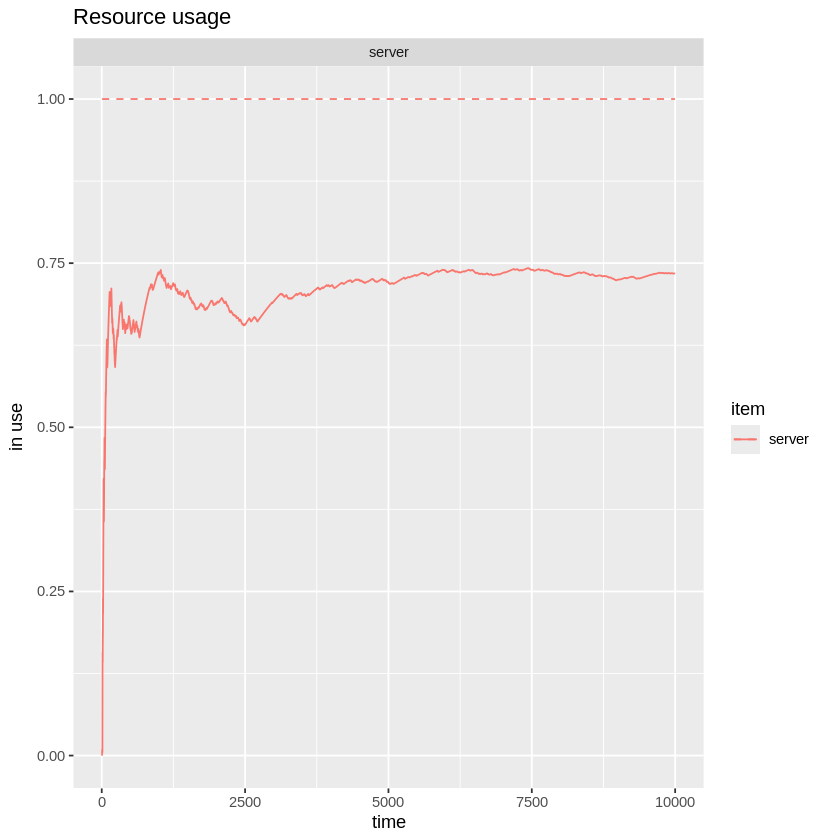

In [21]:
plot(get_mon_resources(env2), metric="usage", items="server")














#ЛР4

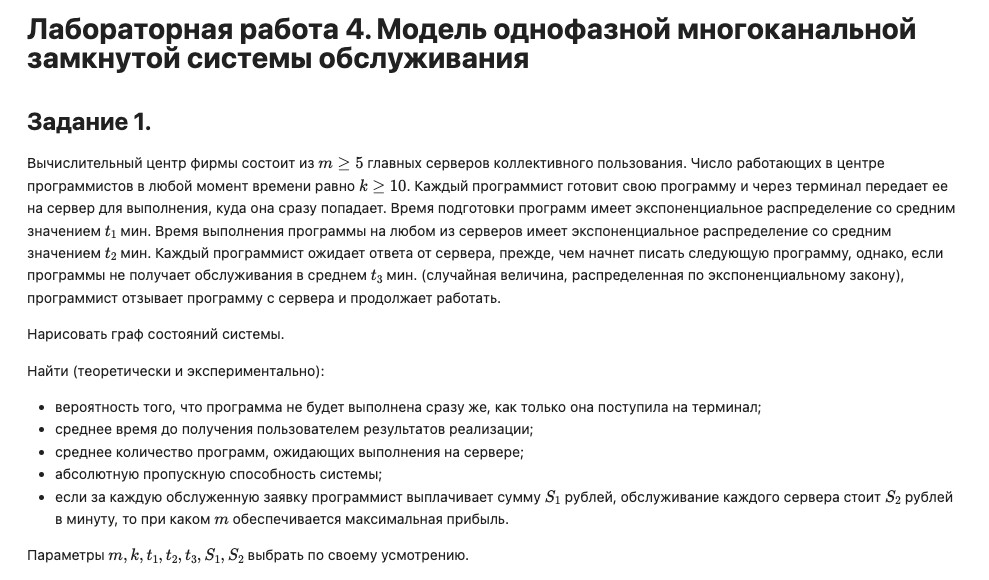

theory = c(0.3575, 21.2762, 0.2368, 0.18553, 3.7106)


In [22]:
m_servers <- 5
k_users   <- 12
t1 <- 40; t2 <- 20; t3 <- 15
lambda <- 1/t1
mu     <- 1/t2
nu     <- 1/t3

S1 <- 500
S2 <- 10

sim_time <- 100000
warmup   <- 10000

set.seed(654321)

In [23]:
env <- simmer("Lab4_MultiServer_Closed")

env <- add_resource(env, "servers",
                    capacity = m_servers,
                    queue_size = Inf)

In [24]:
for (i in 1:k_users) {
  prog_name <- paste0("prog_", i)

  renege_out <- trajectory(paste0(prog_name, "_renege")) %>%
    activate(prog_name) %>%
    leave(1)

  traj <- trajectory(prog_name) %>%
    deactivate(prog_name) %>%
    renege_in(t = function() rexp(1, nu), out = renege_out) %>%
    seize("servers", 1) %>%
    renege_abort() %>%
    timeout(function() rexp(1, mu)) %>%
    release("servers", 1) %>%
    activate(prog_name)

  env <- add_generator(env,
                       name_prefix = prog_name,
                       trajectory = traj,
                       distribution = function() rexp(1, lambda),
                       mon = 2)
}

In [25]:
env <- run(env, until = sim_time)

In [29]:
library(simmer)

get_resource_log <- function(env, resource_name) {
  res <- get_mon_resources(env)
  res <- res[res$resource == resource_name, ]
  res <- res[order(res$time), ]
  return(res)
}

add_time_intervals <- function(res) {
  if (nrow(res) < 2) return(res[0, ])
  res2 <- res
  res2$next_time <- c(res2$time[-1], NA)
  res2 <- res2[!is.na(res2$next_time), ]
  return(res2)
}

apply_warmup_to_resource_log <- function(res2, warmup = 0) {
  if (nrow(res2) == 0) return(res2)
  res2$left <- pmax(res2$time, warmup)
  res2$right <- res2$next_time
  res2$dt <- pmax(res2$right - res2$left, 0)
  res2 <- res2[res2$dt > 0, ]
  return(res2)
}

summarize_resource_stats <- function(res2) {
  if (nrow(res2) == 0) {
    return(list(utilization = NA, avg_queue = NA, avg_system = NA,
                p_queue_positive = NA, total_time = 0))
  }
  total_time <- sum(res2$dt)
  list(
    utilization = sum(res2$server * res2$dt) / total_time,
    avg_queue = sum(res2$queue * res2$dt) / total_time,
    avg_system = sum(res2$system * res2$dt) / total_time,
    p_queue_positive = sum((res2$queue > 0) * res2$dt) / total_time,
    total_time = total_time
  )
}

calc_resource_stats <- function(env, resource_name, warmup = 0) {
  res <- get_resource_log(env, resource_name)
  res2 <- add_time_intervals(res)
  res2 <- apply_warmup_to_resource_log(res2, warmup)
  summarize_resource_stats(res2)
}

get_arrival_log <- function(env, prefix_exclude = NULL) {
  arr <- get_mon_arrivals(env)
  if (!is.null(prefix_exclude)) arr <- arr[!grepl(prefix_exclude, arr$name), ]
  arr
}

prepare_arrival_log <- function(arr, warmup = 0) {
  arr <- arr[arr$start_time >= warmup, ]
  if (nrow(arr) == 0) return(arr)
  arr$system_time <- arr$end_time - arr$start_time
  arr$waiting_time <- pmax(arr$end_time - arr$start_time - arr$activity_time, 0)
  arr
}

calc_arrival_stats <- function(env, warmup = 0, prefix_exclude = NULL) {
  arr <- get_arrival_log(env, prefix_exclude)
  arr <- prepare_arrival_log(arr, warmup)
  finished <- arr[arr$finished == TRUE, ]
  total_time <- if (nrow(arr) > 0) max(arr$end_time, na.rm = TRUE) - warmup else NA
  throughput <- if (!is.na(total_time) && total_time > 0) nrow(finished) / total_time else NA

  list(
    throughput = throughput,
    mean_system_time_all = mean(arr$system_time, na.rm = TRUE),
    mean_waiting_time_all = mean(arr$waiting_time, na.rm = TRUE),
    p_queue_positive = NA
  )
}

In [30]:
res_stats <- calc_resource_stats(env, "servers", warmup)
arr_stats <- calc_arrival_stats(env, warmup)




results <- data.frame(
  Показатель = c(
    "Вероятность того, что программа не будет выполнена сразу (P_ож)",
    "Среднее время до получения результата (W, мин)",
    "Среднее количество программ в очереди (Lq)",
    "Абсолютная пропускная способность A (программ/мин)",
    "Среднее число занятых серверов"
  ),
  Значение = round(c(
    res_stats$p_queue,
    arr_stats$mean_system_time_all,
    res_stats$avg_q,
    arr_stats$throughput,
    res_stats$util
  ), 6)
)
print(results)

                                                       Показатель  Значение
1 Вероятность того, что программа не будет выполнена сразу (P_ож)  0.168075
2                  Среднее время до получения результата (W, мин) 19.568342
3                      Среднее количество программ в очереди (Lq)  0.244674
4              Абсолютная пропускная способность A (программ/мин)  0.186714
5                                  Среднее число занятых серверов  3.709767


ПОИСК ОПТИМАЛЬНОГО КОЛИЧЕСТВА СЕРВЕРОВ

In [31]:
profit_table <- data.frame(m = 3:10, A = NA, Profit = NA)

for (m_test in 3:10) {
  env_test <- simmer(paste0("test_m", m_test))
  env_test <- add_resource(env_test, "servers", capacity = m_test, queue_size = Inf)

  for (i in 1:k_users) {
    prog_name <- paste0("prog_", i)
    renege_out <- trajectory(paste0(prog_name, "_renege")) %>% activate(prog_name) %>% leave(1)

    traj <- trajectory(prog_name) %>%
      deactivate(prog_name) %>%
      renege_in(t = function() rexp(1, nu), out = renege_out) %>%
      seize("servers", 1) %>%
      renege_abort() %>%
      timeout(function() rexp(1, mu)) %>%
      release("servers", 1) %>%
      activate(prog_name)

    env_test <- add_generator(env_test, prog_name, traj, function() rexp(1, lambda), mon = 2)
  }

  env_test <- run(env_test, until = sim_time)
  arr_test <- calc_arrival_stats(env_test, warmup)

  profit_table$A[m_test-2] <- round(arr_test$throughput, 6)
  profit_table$Profit[m_test-2] <- round(arr_test$throughput * S1 - m_test * S2, 2)
}

print(profit_table)
cat("\nОптимальное m =", profit_table$m[which.max(profit_table$Profit)],
    "→ прибыль =", max(profit_table$Profit), "руб/мин\n")

   m        A Profit
1  3 0.135241  37.62
2  4 0.166506  43.25
3  5 0.186642  43.32
4  6 0.195712  37.86
5  7 0.199913  29.96
6  8 0.200641  20.32
7  9 0.199268   9.63
8 10 0.200796   0.40

Оптимальное m = 5 → прибыль = 43.32 руб/мин


Параметры модели

#ЛР5

Для  $n$-канальной системы массового обслуживания с ограничением на длину очереди $m$ составьте дифференциальные уравнения для вероятностей нахождения в заданных состояниях в зависимости от времени. Найдите эти вероятности при определенном в соответствии с вариантом значении $t$, а также при $t\rightarrow \infty$. Канал иногда может выходить из строя. Заявка, которая обслуживается в момент отказа канала ставится в очередь, если там есть места, в противном случае она покидает систему необслуженной. Входящий поток, поток обслуживания, поток отказов и поток восстановления простейшие с соответствующими интенсивностями $\lambda, \mu, \nu, \gamma$. Количество клиентов, от которых могут поступать заявки на обслуживание $k$. Начальные условия $P_0(0)=1$.

Найти (теоретически и экспериментально):
 - вероятность простоя;
 - вероятность образования очереди;
 - абсолютную пропускную способность;
 - среднюю длину очереди;
 - среднее время нахождения заявок в системе;
 - среднее число заявок в системе.
 - среднее время нахождения в очереди.
 - оценить, что приводит к большему увеличению абсолютной пропускной способности системы - увеличение количества каналов или увеличение длины очереди при неизменности остальных характеристик?


theory = c(0.09142, 0.34585, 0.4461, 0.64376, 2.34063, 5.24692, 1.44316, 0.000025)



вводим наши значения

In [41]:
lambda <- 0.09391977
mu    <- 0.2621519
nu    <- 0.174463
gamma <- 0.6805274

k <- 9
n <- 3
m <- 7

sim_time <- 100000
warmup   <- 10000

set.seed(111)


создаем и запускаем модель

In [43]:
env <- simmer("LR5")

env <- add_resource(env, "channels",
                    capacity = n,
                    queue_size = m,
                    queue_size_strict = TRUE,
                    preemptive = TRUE)

failure_traj <- trajectory("failure") %>%
  set_prioritization(c(10, 10, FALSE)) %>%
  timeout(function() rexp(1, nu)) %>%
  seize("channels", 1) %>%
  timeout(function() rexp(1, gamma)) %>%
  release("channels", 1) %>%
  rollback(4, Inf)

for (ch in 1:n) {
  env <- add_generator(env, paste0("repair_", ch), failure_traj, at(0), mon = 2)
}

for (i in 1:k) {
  client_name <- paste0("client_", i)

  traj <- trajectory(client_name) %>%
    deactivate(client_name) %>%
    seize("channels", 1) %>%
    timeout(function() rexp(1, mu)) %>%
    release("channels", 1) %>%
    activate(client_name)

  env <- add_generator(env,
                       name_prefix = client_name,
                       trajectory = traj,
                       distribution = function() rexp(1, lambda),
                       mon = 2)
}

env <- run(env, until = sim_time)


res <- calc_resource_stats(env, "channels", warmup)
arr <- calc_arrival_stats(env, warmup, "repair_")

arrivals <- get_mon_arrivals(env)
arrivals <- arrivals[!grepl("repair_", arrivals$name), ]
arrivals <- arrivals[arrivals$start_time >= warmup, ]

if (nrow(arrivals) > 0) {
  events <- data.frame(
    time = c(arrivals$start_time, arrivals$end_time),
    change = c(rep(1, nrow(arrivals)), rep(-1, nrow(arrivals)))
  )
  events <- events[order(events$time, -events$change), ]
  events$count <- cumsum(events$change)
  events$next_time <- c(events$time[-1], NA)
  events <- events[!is.na(events$next_time), ]
  events$dt <- events$next_time - events$time
  events <- events[events$dt > 0, ]

  total_t <- sum(events$dt)
  L   <- sum(events$count * events$dt) / total_t
  P0  <- sum((events$count == 0) * events$dt) / total_t
  Ploss <- mean(!arrivals$finished)
} else {
  L <- P0 <- Ploss <- NA
}

W  <- arr$mean_system_time_all
Wq <- if (arr$throughput > 0) res$avg_queue / arr$throughput else NA


results <- data.frame(
  Характеристика = c(
    "Вероятность простоя (P0)",
    "Вероятность образования очереди",
    "Абсолютная пропускная способность",
    "Средняя длина очереди",
    "Среднее число заявок в системе (L)",
    "Среднее время в системе (W)",
    "Среднее время в очереди (Wq)",
    "Вероятность потери заявки"
  ),
  Эксперимент = round(c(
    P0,
    res$p_queue_positive,
    arr$throughput,
    res$avg_queue,
    L,
    W,
    Wq,
    Ploss
  ), 6)
)

print(results)

                      Характеристика Эксперимент
1           Вероятность простоя (P0)    0.091411
2    Вероятность образования очереди    0.345849
3  Абсолютная пропускная способность    0.446078
4              Средняя длина очереди    0.643756
5 Среднее число заявок в системе (L)    2.340625
6        Среднее время в системе (W)    5.246922
7       Среднее время в очереди (Wq)    1.443146
8          Вероятность потери заявки    0.000025


#Симуляция совпадает с теоретическими выводами